Shapes: (120, 128, 430) (25, 128, 430) (26, 128, 430) | classes: ['Hijaz', 'Nahawand', 'Saba']
Epoch 01 | train 0.358/1.149  val 0.320/1.099
Epoch 02 | train 0.617/0.880  val 0.320/1.325
Epoch 03 | train 0.658/0.818  val 0.640/0.808
Epoch 04 | train 0.675/0.732  val 0.800/0.583
Epoch 05 | train 0.850/0.474  val 0.920/0.380
Epoch 06 | train 0.900/0.328  val 0.920/0.248
Epoch 07 | train 0.933/0.242  val 0.960/0.206
Epoch 08 | train 0.950/0.194  val 0.960/0.104
Epoch 09 | train 0.942/0.174  val 0.960/0.103
Epoch 10 | train 0.942/0.174  val 0.960/0.190
Epoch 11 | train 0.975/0.134  val 1.000/0.094
Epoch 12 | train 0.983/0.100  val 0.960/0.183
Epoch 13 | train 0.983/0.085  val 1.000/0.050
Epoch 14 | train 0.975/0.080  val 0.960/0.136
Epoch 15 | train 0.975/0.079  val 1.000/0.039
Epoch 16 | train 0.983/0.087  val 1.000/0.040
Epoch 17 | train 0.992/0.052  val 0.960/0.082
Epoch 18 | train 0.992/0.038  val 1.000/0.056
Epoch 19 | train 1.000/0.020  val 1.000/0.044
Epoch 20 | train 1.000/0.009  v

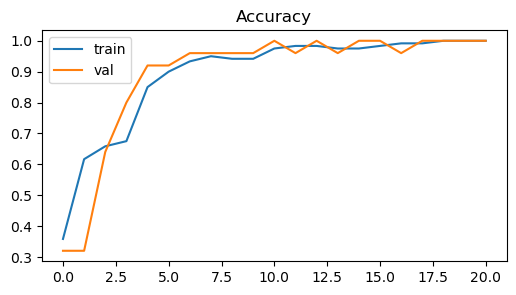

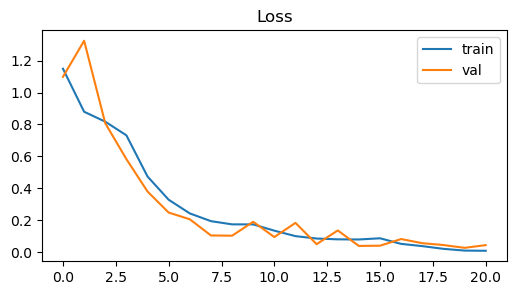

Best val acc: 1.000

✅ Test Accuracy: 0.962
              precision    recall  f1-score   support

       Hijaz       0.89      1.00      0.94         8
    Nahawand       1.00      1.00      1.00         9
        Saba       1.00      0.89      0.94         9

    accuracy                           0.96        26
   macro avg       0.96      0.96      0.96        26
weighted avg       0.97      0.96      0.96        26



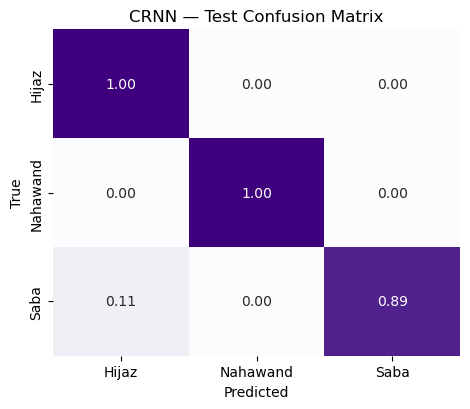

💾 Saved CRNN → C:\Users\nabal\Documents\FYP\models_deep\crnn_mel_best.pth
📝 Saved summary → C:\Users\nabal\Documents\FYP\reports\stage5_crnn_summary.txt


In [1]:
# =========================
# Stage 5 — CRNN (Conv + BiGRU) on Mel-Spectrograms
# =========================
import os, joblib, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ------------- Paths / config -------------
BASE      = r"C:\Users\nabal\Documents\FYP"
MEL_DIR   = os.path.join(BASE, "mel_spectrograms_v1")
MODEL_DIR = os.path.join(BASE, "models_deep"); os.makedirs(MODEL_DIR, exist_ok=True)
REPORTS   = os.path.join(BASE, "reports"); os.makedirs(REPORTS, exist_ok=True)

SEED = 42
BATCH = 16
EPOCHS = 60
LR = 1e-3
PATIENCE = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ------------- Reproducibility -------------
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s); torch.backends.cudnn.deterministic = True
set_seed()

# ------------- Load data -------------
X_tr = np.load(os.path.join(MEL_DIR, "X_train.npy"))  # (N, 128, T)
y_tr = np.load(os.path.join(MEL_DIR, "y_train.npy"))  # (N,)
X_va = np.load(os.path.join(MEL_DIR, "X_val.npy"))
y_va = np.load(os.path.join(MEL_DIR, "y_val.npy"))
X_te = np.load(os.path.join(MEL_DIR, "X_test.npy"))
y_te = np.load(os.path.join(MEL_DIR, "y_test.npy"))
le   = joblib.load(os.path.join(MEL_DIR, "label_encoder.joblib"))  # dict or LabelEncoder
# handle dict/LabelEncoder both
if hasattr(le, "classes_"):
    classes = list(le.classes_)
else:
    # dict mapping str->int
    inv = {v:k for k,v in le.items()}
    classes = [inv[i] for i in range(len(inv))]
n_classes = len(classes)

print("Shapes:", X_tr.shape, X_va.shape, X_te.shape, "| classes:", classes)

# ------------- Datasets with light augmentation -------------
def time_mask(spec, max_width=30):
    T = spec.shape[1]
    w = np.random.randint(0, max_width+1)
    if w == 0 or w >= T: return spec
    t0 = np.random.randint(0, T-w+1)
    spec[:, t0:t0+w] = 0.0
    return spec

def freq_mask(spec, max_width=16):
    F = spec.shape[0]
    w = np.random.randint(0, max_width+1)
    if w == 0 or w >= F: return spec
    f0 = np.random.randint(0, F-w+1)
    spec[f0:f0+w, :] = 0.0
    return spec

def add_noise(spec, sigma=0.02):
    return spec + np.random.normal(0, sigma, size=spec.shape).astype(spec.dtype)

class MelSet(Dataset):
    def __init__(self, X, y, train=False):
        self.X = X.astype(np.float32)  # (N, 128, T)
        self.y = y.astype(np.int64)
        self.train = train
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        M = self.X[idx].copy()
        if self.train:
            # simple SpecAugment flavors (order: noise -> mask)
            if np.random.rand() < 0.50: M = add_noise(M, sigma=0.015)
            if np.random.rand() < 0.50: M = time_mask(M, max_width=36)
            if np.random.rand() < 0.50: M = freq_mask(M, max_width=18)
        # to tensor [B, C=1, F=128, T]
        M = torch.from_numpy(M).unsqueeze(0)  # (1,128,T)
        label = torch.tensor(self.y[idx])
        return M, label

tr_ds = MelSet(X_tr, y_tr, train=True)
va_ds = MelSet(X_va, y_va, train=False)
te_ds = MelSet(X_te, y_te, train=False)

train_loader = DataLoader(tr_ds, batch_size=BATCH, shuffle=True,  drop_last=False)
val_loader   = DataLoader(va_ds, batch_size=BATCH, shuffle=False, drop_last=False)
test_loader  = DataLoader(te_ds, batch_size=BATCH, shuffle=False, drop_last=False)

# ------------- CRNN model -------------
class CRNN(nn.Module):
    def __init__(self, n_classes=3, n_mels=128, cnn_out=128, rnn_hidden=128, rnn_layers=1, bidir=True, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout(dropout),  # (F/2, T/2)

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout(dropout),  # (F/4, T/4)

            nn.Conv2d(64, cnn_out, kernel_size=3, padding=1), nn.BatchNorm2d(cnn_out), nn.ReLU(),
        )
        self.rnn_hidden = rnn_hidden
        self.bidir = bidir
        self.gru = nn.GRU(input_size=cnn_out*(n_mels//4), hidden_size=rnn_hidden,
                          num_layers=rnn_layers, batch_first=True, bidirectional=bidir, dropout=0.0)
        self.classifier = nn.Sequential(
            nn.Linear(rnn_hidden*(2 if bidir else 1), 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        # x: (B,1,128,T)
        z = self.features(x)          # (B, C=cnn_out, F=128/4, T=T/4)
        B, C, F, T = z.shape
        z = z.permute(0, 3, 1, 2).contiguous()  # (B, T, C, F)
        z = z.view(B, T, C*F)                   # (B, T, feat)
        out, _ = self.gru(z)                    # (B, T, H*dir)
        # temporal aggregation: mean-pool across time
        out = out.mean(dim=1)                   # (B, H*dir)
        logits = self.classifier(out)           # (B, n_classes)
        return logits

model = CRNN(n_classes=n_classes).to(DEVICE)

# ------------- Class weights (handle imbalance by reciter, etc.) -------------
class_counts = np.bincount(y_tr, minlength=n_classes).astype(np.float32)
weights = class_counts.sum() / (class_counts + 1e-6)
weights = weights / weights.mean()
class_weights_t = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=4)

# ------------- Train / eval loops -------------
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if train: optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        if train:
            loss.backward()
            optimizer.step()
        preds = logits.argmax(1)
        total += yb.size(0)
        correct += (preds == yb).sum().item()
        loss_sum += loss.item() * yb.size(0)
    return correct/total, loss_sum/total

best_val, best_state, patience = 0.0, None, 0
hist = {"tr_acc":[], "va_acc":[], "tr_loss":[], "va_loss":[]}

for epoch in range(1, EPOCHS+1):
    tr_acc, tr_loss = run_epoch(train_loader, True)
    va_acc, va_loss = run_epoch(val_loader,   False)
    scheduler.step(va_loss)
    hist["tr_acc"].append(tr_acc); hist["va_acc"].append(va_acc)
    hist["tr_loss"].append(tr_loss); hist["va_loss"].append(va_loss)
    print(f"Epoch {epoch:02d} | train {tr_acc:.3f}/{tr_loss:.3f}  val {va_acc:.3f}/{va_loss:.3f}")
    if va_acc > best_val:
        best_val, best_state, patience = va_acc, {k:v.cpu().clone() for k,v in model.state_dict().items()}, 0
    else:
        patience += 1
        if patience >= PATIENCE:
            print("Early stopping."); break

# restore best
if best_state is not None: model.load_state_dict(best_state)

# ------------- Curves -------------
plt.figure(figsize=(6,3)); plt.plot(hist["tr_acc"],label="train"); plt.plot(hist["va_acc"],label="val"); plt.legend(); plt.title("Accuracy"); plt.show()
plt.figure(figsize=(6,3)); plt.plot(hist["tr_loss"],label="train"); plt.plot(hist["va_loss"],label="val"); plt.legend(); plt.title("Loss"); plt.show()
print(f"Best val acc: {best_val:.3f}")

# ------------- Test evaluation -------------
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        preds = logits.argmax(1).cpu().numpy().tolist()
        y_pred.extend(preds)
        y_true.extend(yb.numpy().tolist())

acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {acc:.3f}")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred, normalize="true")
plt.figure(figsize=(4.8,4.2))
sns.heatmap(cm, annot=True, cmap="Purples", xticklabels=classes, yticklabels=classes, fmt=".2f", cbar=False)
plt.title("CRNN — Test Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()

# ------------- Save model -------------
MODEL_PATH = os.path.join(MODEL_DIR, "crnn_mel_best.pth")
torch.save({"state_dict": model.state_dict(),
            "classes": classes,
            "config": {"n_mels":128, "lr":LR, "epochs":EPOCHS, "batch":BATCH}},
           MODEL_PATH)
print("💾 Saved CRNN →", MODEL_PATH)

# ------------- Save brief report -------------
with open(os.path.join(REPORTS, "stage5_crnn_summary.txt"), "w", encoding="utf-8") as f:
    f.write(f"CRNN (Conv+BiGRU) on Mel spectrograms\n")
    f.write(f"Classes: {classes}\n")
    f.write(f"Best Val Acc: {best_val:.3f}\n")
    f.write(f"Test Acc: {acc:.3f}\n")
print("📝 Saved summary →", os.path.join(REPORTS, "stage5_crnn_summary.txt"))


Saved confusion matrix.


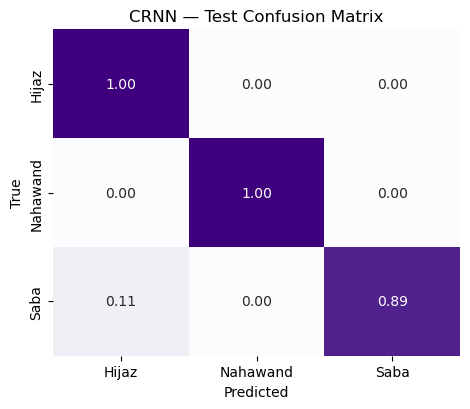

In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

# y_true, y_pred already computed in your last cell
cm = confusion_matrix(y_true, y_pred, normalize="true")
plt.figure(figsize=(4.8,4.2))
sns.heatmap(cm, annot=True, cmap="Purples",
            xticklabels=classes, yticklabels=classes,
            fmt=".2f", cbar=False)
plt.title("CRNN — Test Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(r"C:\Users\nabal\Documents\FYP\reports\crnn_cm_test.png", dpi=200)
print("Saved confusion matrix.")


In [3]:
import pandas as pd
comp = pd.DataFrame({
    "Model": ["Random Forest","SVM (RBF)","XGBoost","CRNN (Mel)"],
    "Val Acc": [0.920, 0.920, 0.880, round(best_val,3)],
    "Test Acc":[0.923, 0.885, 0.885, 0.962]
})
comp.to_csv(r"C:\Users\nabal\Documents\FYP\reports\model_comparison.csv", index=False)
print(comp)


           Model  Val Acc  Test Acc
0  Random Forest     0.92     0.923
1      SVM (RBF)     0.92     0.885
2        XGBoost     0.88     0.885
3     CRNN (Mel)     1.00     0.962


In [7]:
import os, torch, torch.nn as nn

# 1) Put model on CPU and in eval
MODEL_DIR = r"C:\Users\nabal\Documents\FYP\models_deep"
model.eval().cpu()

# 2) Wrap model to ensure float32 and no training-time branches
class InferenceWrapper(nn.Module):
    def __init__(self, m): 
        super().__init__(); self.m = m.eval()
    def forward(self, x):
        x = x.to(torch.float32)
        with torch.no_grad():
            return self.m(x)

wrapped = InferenceWrapper(model)

# 3) Fixed dummy input (same T you trained with: 430)
dummy = torch.zeros(1, 1, 128, 430, dtype=torch.float32)  # (B,C,F,T)

# 4) Export with legacy path (dynamo=False) and no dynamic_axes
onnx_path = os.path.join(MODEL_DIR, "crnn_mel_best.onnx")
torch.onnx.export(
    wrapped, dummy, onnx_path,
    input_names=["mel"], output_names=["logits"],
    opset_version=13,          # 13 is stable
    do_constant_folding=True,
    training=torch.onnx.TrainingMode.EVAL,
    dynamo=False               # << use legacy exporter
)
print("✅ ONNX saved →", onnx_path)


C:\Users\nabal\AppData\Local\Temp\ipykernel_22840\1005323923.py:23: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


✅ ONNX saved → C:\Users\nabal\Documents\FYP\models_deep\crnn_mel_best.onnx
